In [5]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

WD masses in binary systems range from 0.8 - 1.14 solar masses, and avg radius is 0.01 solar radii
NS avg mass 1.4 solar masses, avg radius is 15km
BH masses (stellar-mass) 5-150 solar masses, (radius around 30 km for 10 solar masses)


In [6]:
N = 5000
m_wd = 0.63
m_s = 1.1
r_wd = 0.0133 * u.R_sun 
r_s = 1.0 * u.R_sun
a = 10 * u.R_sun
e = 0 #0.061
period = 683.267 
L_star = 1.0
L_wd = 0.001
t = np.linspace(0, (period*u.day).to(u.yr).value, N) * u.yr
d = 50 * u.pc
inc = 90 *u.deg

prob something with E calculation

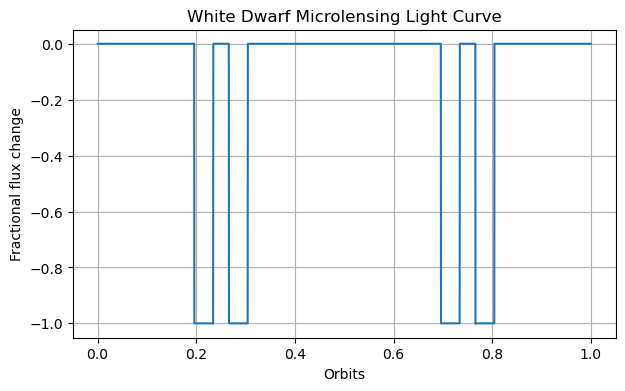

In [7]:
test1 = WDBinary(m_wd, r_wd, L_wd, m_s, r_s, L_star, e, a, d, t, inc=inc, period=period)
test1.plot_light_curve(t)

## MC Calcualtion ##

In [94]:
def einstein_radius_circ(M, a, D):
    r_E = np.sqrt((2 * G * M * a) / (c**2 * D * (D + a)))
    return (r_E * D).to(u.Rsun)
    
def transit_prob(r_E, r_star, a):
    return (r_E + r_star) / a

In [95]:
def sample_rstar_from_mstar(Mstar, N, sigma_logR=0.1):
    if Mstar.value < 1.0:
        alpha = 0.8
    elif Mstar.value < 10.0:
        alpha = 0.57
    else:
        alpha = 0.3

    Rmean = Mstar.value**alpha
    logR = np.log10(Rmean) + np.random.normal(0, sigma_logR, N)
    return 10**logR * u.Rsun

def sample_cosi(N):
    return np.random.uniform(0, 1, N)

def transit_condition(a, cosi, Rstar, rE):
    r = a * cosi

    if Rstar.size > 1:
        rE_arr = rE

        if rE.size == 1:
            rE_arr = np.ones(Rstar.size) * rE
        
        cond = Rstar + rE_arr

    return r < cond

In [96]:
def transit_prob_Mlens(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [97]:
def transit_prob_a(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    Rstar = sample_rstar_from_mstar(Mstar, N, sigma_logR)
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [98]:
def transit_prob_Rstar(a, Mstar, Mlens, D, N=100000,sigma_logR=0.1):
    cosi = sample_cosi(N)
    rE = einstein_radius_circ(Mlens, a, D)

    obs = transit_condition(a, cosi, Rstar, rE)
    return np.sum(obs), obs.size

In [130]:
a_vals = np.logspace(-2, 1, 50) * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=0.6*u.Msun, D=26.8*u.pc)
           for a in a_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(a_vals)


[0.47976 0.41263 0.35886 0.31445 0.27428 0.24038 0.20579 0.17706 0.15508
 0.13342 0.11411 0.10104 0.08855 0.07629 0.06669 0.05712 0.0504  0.04548
 0.03925 0.03394 0.02944 0.02531 0.02157 0.01901 0.01522 0.01439 0.01301
 0.01071 0.00945 0.00814 0.00744 0.00623 0.00518 0.00438 0.00402 0.00345
 0.00252 0.00271 0.00228 0.0021  0.00176 0.00135 0.00141 0.00125 0.00095
 0.0009  0.00074 0.00066 0.00068 0.00049]
[47976 41263 35886 31445 27428 24038 20579 17706 15508 13342 11411 10104
  8855  7629  6669  5712  5040  4548  3925  3394  2944  2531  2157  1901
  1522  1439  1301  1071   945   814   744   623   518   438   402   345
   252   271   228   210   176   135   141   125    95    90    74    66
    68    49]
[ 0.01        0.01151395  0.01325711  0.01526418  0.01757511  0.0202359
  0.02329952  0.02682696  0.03088844  0.0355648   0.04094915  0.04714866
  0.05428675  0.06250552  0.07196857  0.08286428  0.09540955  0.10985411
  0.12648552  0.14563485  0.16768329  0.19306977  0.22229965  0.25595

Text(0.5, 0, 'a (AU)')

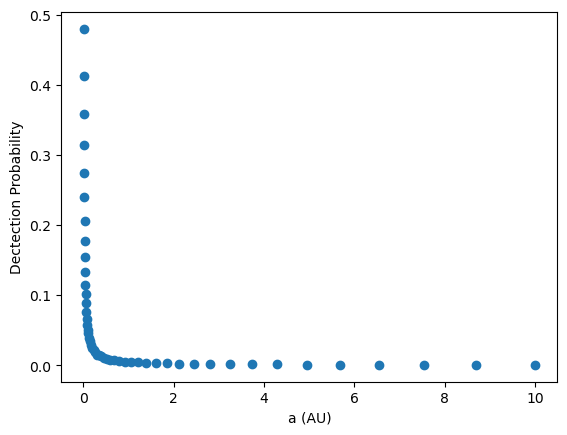

In [131]:
plt.scatter(a_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("a (AU)")

In [132]:
Mlens_vals = np.linspace(0.1, 10, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.pc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00465 0.00495 0.00451 0.00494 0.00474 0.00478 0.00503 0.00494 0.00509
 0.00493 0.0048  0.00474 0.00479 0.00478 0.00484 0.00477 0.00452 0.00497
 0.00508 0.00495 0.00471 0.00464 0.00526 0.00522 0.00522 0.0046  0.0046
 0.00458 0.00482 0.00446 0.00478 0.00509 0.00466 0.00473 0.00492 0.00468
 0.00458 0.00501 0.00492 0.0053  0.00513 0.00486 0.00481 0.00471 0.00479
 0.00462 0.00477 0.00508 0.00491 0.00439 0.00486 0.0046  0.00481 0.00484
 0.00511 0.00466 0.00507 0.00493 0.00449 0.00498 0.00527 0.00477 0.00512
 0.00506 0.00489 0.00465 0.00496 0.00513 0.00448 0.00469 0.00484 0.00463
 0.0047  0.00477 0.00493 0.00504 0.0049  0.00506 0.00503 0.00493 0.00476
 0.00498 0.00528 0.00483 0.00488 0.00468 0.00441 0.00477 0.00453 0.005
 0.00526 0.00464 0.00474 0.00448 0.0052  0.00468 0.00523 0.00509 0.00522
 0.00495 0.00495 0.00475 0.00503 0.00448 0.00501 0.0046  0.00483 0.00461
 0.00469 0.0049  0.00509 0.00455 0.0048  0.00473 0.00464 0.00496 0.00457
 0.00474 0.00471 0.00531 0.00503 0.00491 0.00506 0.004

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

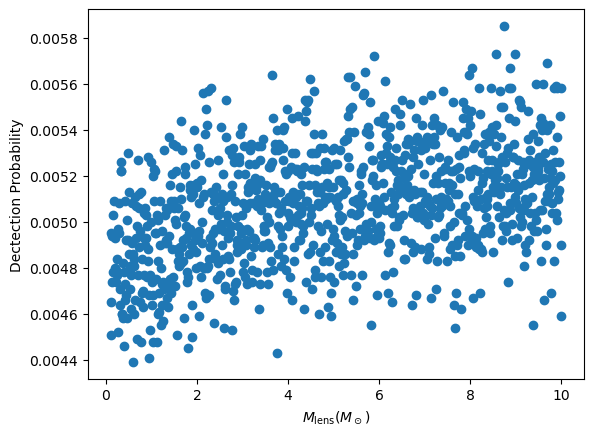

In [133]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")

In [134]:
Mstar_vals = np.linspace(0.2, 5, 1000) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=M, Mlens=0.6*u.Msun, D=26.8*u.pc)
           for M in Mstar_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mstar_vals)


[0.00141 0.00158 0.00138 0.00146 0.00162 0.00158 0.00158 0.00153 0.00167
 0.00156 0.00172 0.00159 0.00153 0.00171 0.00191 0.00177 0.00199 0.00185
 0.00173 0.00163 0.00177 0.0019  0.00215 0.00185 0.00221 0.00185 0.00207
 0.0018  0.00212 0.002   0.00242 0.00225 0.00247 0.00222 0.00228 0.00242
 0.0023  0.00214 0.00241 0.00243 0.00234 0.00231 0.00238 0.00242 0.00236
 0.00256 0.00235 0.00236 0.00255 0.00219 0.00287 0.00268 0.00255 0.00297
 0.00252 0.00292 0.00271 0.00245 0.00281 0.00311 0.00264 0.00243 0.00262
 0.00306 0.00258 0.00292 0.00297 0.00292 0.00316 0.00289 0.00322 0.00306
 0.00308 0.00312 0.00299 0.00299 0.00272 0.00373 0.00302 0.00321 0.0033
 0.00331 0.00341 0.00331 0.00306 0.0036  0.00355 0.00337 0.00325 0.00326
 0.00316 0.00327 0.00378 0.00363 0.00364 0.00318 0.00379 0.0036  0.00387
 0.00356 0.00337 0.00369 0.00366 0.00353 0.00363 0.0039  0.00367 0.00359
 0.0041  0.00402 0.00389 0.00394 0.00378 0.00372 0.00393 0.00402 0.0038
 0.00385 0.00371 0.0041  0.00415 0.00451 0.00412 0.00

Text(0.5, 0, '$M_\\mathrm{*} (M_\\odot)$')

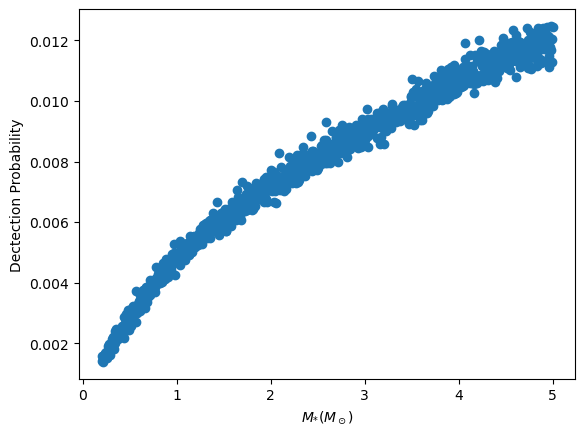

In [135]:
plt.scatter(Mstar_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{*} (M_\odot)$")

## BH SLB DETECABILITY RECALCULATION ##

In [136]:
def sample_bh_masses(N, m_min=5.0, m_max=50.0, alpha=2.3):
    inv = 1.0 - alpha
    c0 = m_min**inv
    c1 = m_max**inv
    r = np.random.rand(N)
    masses = (c0 + (c1 - c0)*r)**(1.0/inv)
    return masses

# replace your linspace with this:
Mlens_vals = sample_bh_masses(100) * u.Msun
a = 1.0 * u.au

results = [transit_prob_a(a, Mstar=1*u.Msun, Mlens=Ml, D=26.8*u.pc)
           for Ml in Mlens_vals]

hits = np.array([r[0] for r in results])
size = np.array([r[1] for r in results])

P = hits / size

print(P)
print(hits)
print(Mlens_vals)

[0.00539 0.00551 0.00536 0.00568 0.00478 0.00501 0.00531 0.00479 0.00532
 0.00497 0.00515 0.0053  0.00526 0.0053  0.00545 0.0055  0.00602 0.00523
 0.00548 0.00511 0.005   0.00507 0.00497 0.00497 0.00494 0.00537 0.00533
 0.00543 0.00523 0.00534 0.00527 0.00519 0.00473 0.00468 0.00502 0.0048
 0.00517 0.00561 0.00513 0.00552 0.00531 0.00565 0.00535 0.00511 0.00508
 0.0049  0.00545 0.00548 0.00478 0.00558 0.00516 0.00485 0.00522 0.00548
 0.00553 0.00525 0.00533 0.00512 0.00538 0.00549 0.00513 0.00519 0.00541
 0.0056  0.00504 0.00494 0.00601 0.00539 0.0053  0.00517 0.00495 0.00489
 0.00512 0.00541 0.00445 0.00535 0.00522 0.0054  0.00574 0.00506 0.00574
 0.00533 0.00476 0.005   0.00618 0.00497 0.00531 0.00529 0.00498 0.00561
 0.00584 0.00513 0.00509 0.00561 0.0051  0.00546 0.00441 0.00551 0.00544
 0.0053 ]
[539 551 536 568 478 501 531 479 532 497 515 530 526 530 545 550 602 523
 548 511 500 507 497 497 494 537 533 543 523 534 527 519 473 468 502 480
 517 561 513 552 531 565 535 511 508 490 5

Text(0.5, 0, '$M_\\mathrm{lens} (M_\\odot)$')

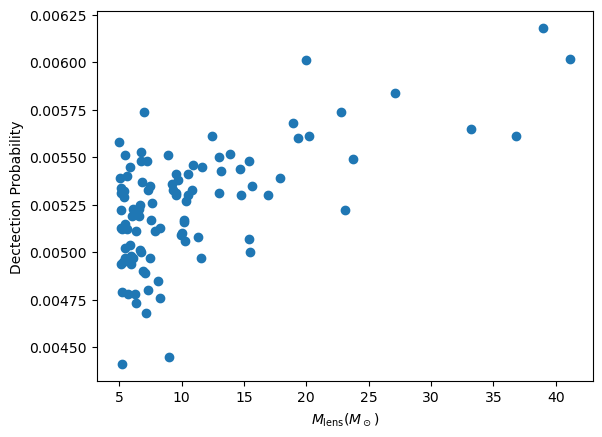

In [137]:
plt.scatter(Mlens_vals, P)
plt.ylabel("Dectection Probability")
plt.xlabel("$M_\mathrm{lens} (M_\odot)$")